In [1]:
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=73b9ecbefcc26e9d89a91cbad42da105cececf051e0659ef6659de6e6ea4812c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (768, 9)


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Outcome"].value_counts())

Dataset shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [7]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    print(
        column,
        "zero values:",
        (df[column] == 0).sum()
    )

Glucose zero values: 5
BloodPressure zero values: 35
SkinThickness zero values: 227
Insulin zero values: 374
BMI zero values: 11


In [8]:
df[zero_columns] = df[zero_columns].replace(0, np.nan)

for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

print("Invalid zero values handled successfully!")

Invalid zero values handled successfully!


In [9]:
print("Missing values after preprocessing:")

print(df.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print("Outcome")

Input features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target variable:
Outcome


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 77.92 %


In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.88      0.84       100
    Diabetes       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



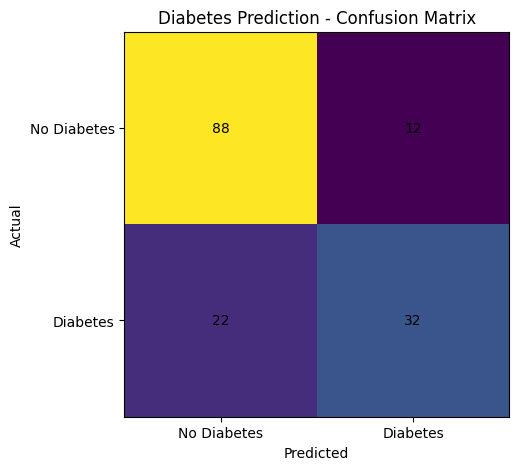

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Diabetes Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.yticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [16]:
import shap

# Create SHAP explainer
shap_explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test data
shap_values = shap_explainer.shap_values(X_test)

print("SHAP values generated successfully!")

SHAP values generated successfully!


In [17]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Class 0 shape:", shap_values[0].shape)
    print("Class 1 shape:", shap_values[1].shape)
else:
    print("SHAP shape:", np.array(shap_values).shape)

<class 'numpy.ndarray'>
SHAP shape: (154, 8, 2)


In [18]:
# Get SHAP values for Diabetes class

if isinstance(shap_values, list):
    diabetes_shap = shap_values[1]
else:
    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        # Handle newer SHAP format
        diabetes_shap = shap_array[:, :, 1]
    else:
        diabetes_shap = shap_array

print("Diabetes SHAP shape:", diabetes_shap.shape)

Diabetes SHAP shape: (154, 8)


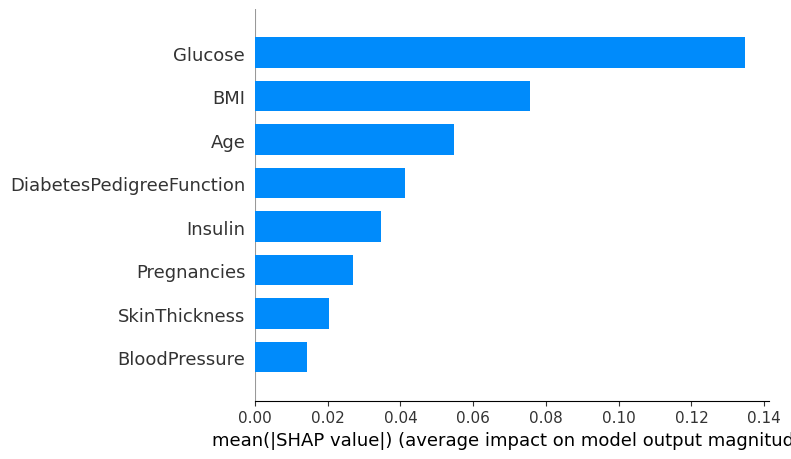

In [19]:
shap.summary_plot(
    diabetes_shap,
    X_test,
    plot_type="bar"
)

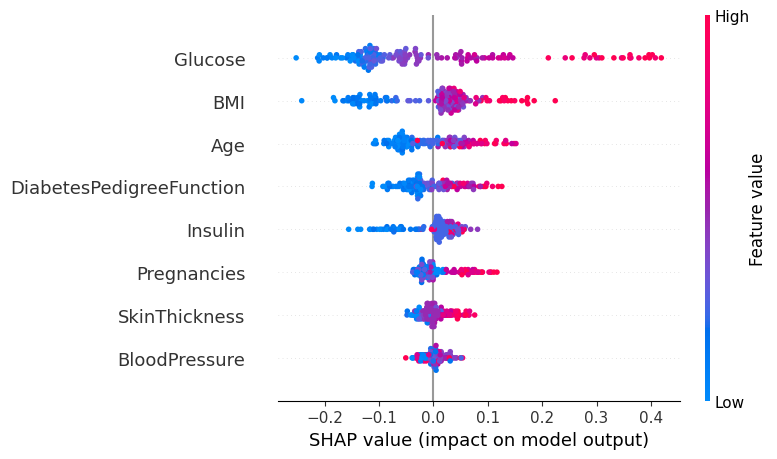

In [20]:
shap.summary_plot(
    diabetes_shap,
    X_test
)

In [21]:
patient_index = 0

patient = X_test.iloc[[patient_index]]

print("Patient medical information:")
display(patient)

Patient medical information:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,29.0,125.0,27.4,0.294,40


In [22]:
patient_prediction = model.predict(patient)[0]
patient_probability = model.predict_proba(patient)[0]

if patient_prediction == 1:
    result = "Diabetes"
else:
    result = "No Diabetes"

print("Prediction:", result)

print(
    "Probability of No Diabetes:",
    round(patient_probability[0] * 100, 2),
    "%"
)

print(
    "Probability of Diabetes:",
    round(patient_probability[1] * 100, 2),
    "%"
)

Prediction: Diabetes
Probability of No Diabetes: 33.0 %
Probability of Diabetes: 67.0 %


In [23]:
patient_explanation = shap_explainer(
    patient
)

print("Individual SHAP explanation generated!")

Individual SHAP explanation generated!


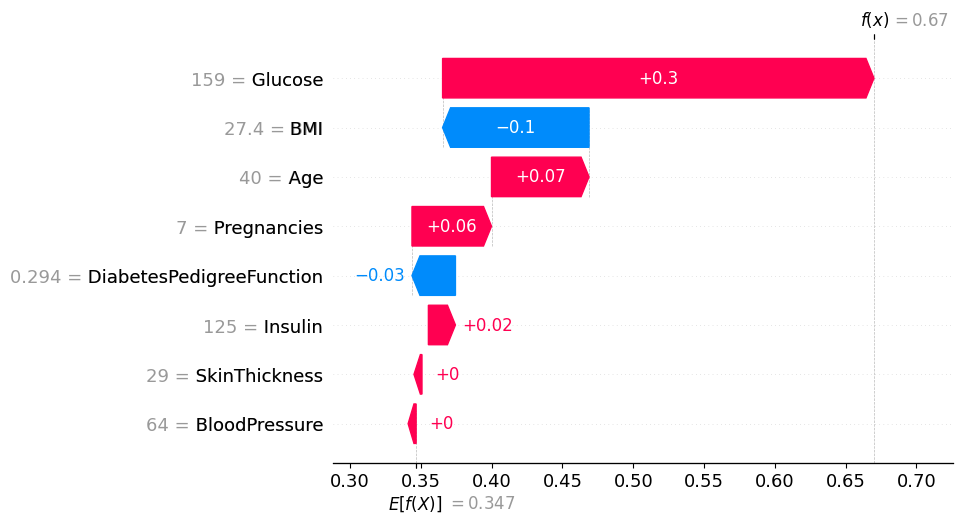

In [24]:
shap.plots.waterfall(
    patient_explanation[0, :, 1]
)

In [25]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Diabetes", "Diabetes"],
    mode="classification",
    random_state=42
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [26]:
lime_explanation = lime_explainer.explain_instance(
    X_test.iloc[patient_index].values,
    model.predict_proba,
    num_features=8
)

print("LIME explanation generated successfully!")

LIME explanation generated successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [27]:
lime_explanation.show_in_notebook(
    show_table=True
)

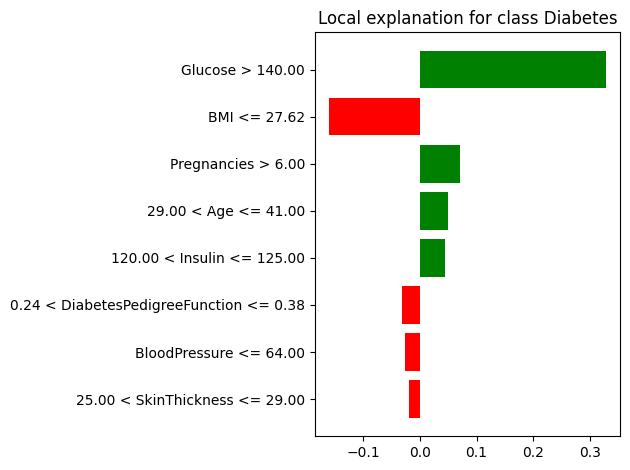

In [28]:
lime_explanation.as_pyplot_figure()

plt.tight_layout()
plt.show()

In [29]:
def explain_patient(patient_index=0):

    # Get patient
    patient = X_test.iloc[[patient_index]]

    print("=" * 70)
    print("EXPLAINABLE AI - DIABETES PREDICTION")
    print("=" * 70)

    print("\nPatient Medical Information:")
    display(patient)

    # -----------------------------
    # Prediction
    # -----------------------------

    prediction = model.predict(patient)[0]
    probability = model.predict_proba(patient)[0]

    if prediction == 1:
        result = "Diabetes"
    else:
        result = "No Diabetes"

    print("\nPrediction:", result)

    print(
        "No Diabetes Probability:",
        round(probability[0] * 100, 2),
        "%"
    )

    print(
        "Diabetes Probability:",
        round(probability[1] * 100, 2),
        "%"
    )

    # -----------------------------
    # SHAP
    # -----------------------------

    print("\n" + "=" * 70)
    print("SHAP EXPLANATION")
    print("=" * 70)

    patient_explanation = shap_explainer(patient)

    shap.plots.waterfall(
        patient_explanation[0, :, 1]
    )

    # -----------------------------
    # LIME
    # -----------------------------

    print("\n" + "=" * 70)
    print("LIME EXPLANATION")
    print("=" * 70)

    lime_explanation = lime_explainer.explain_instance(
        X_test.iloc[patient_index].values,
        model.predict_proba,
        num_features=8
    )

    lime_explanation.as_pyplot_figure()

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Final explanation
    # -----------------------------

    print("\n" + "=" * 70)
    print("FINAL INTERPRETATION")
    print("=" * 70)

    if prediction == 1:
        print(
            "The ML model predicts that this patient is likely "
            "to have diabetes."
        )
    else:
        print(
            "The ML model predicts that this patient is likely "
            "not to have diabetes."
        )

    print(
        "\nSHAP explains how each feature contributed "
        "to this prediction."
    )

    print(
        "LIME explains which features were important "
        "for this specific patient."
    )

    print(
        "\nNote: This prediction is for academic demonstration "
        "only and is not a medical diagnosis."
    )

EXPLAINABLE AI - DIABETES PREDICTION

Patient Medical Information:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,29.0,125.0,27.4,0.294,40



Prediction: Diabetes
No Diabetes Probability: 33.0 %
Diabetes Probability: 67.0 %

SHAP EXPLANATION


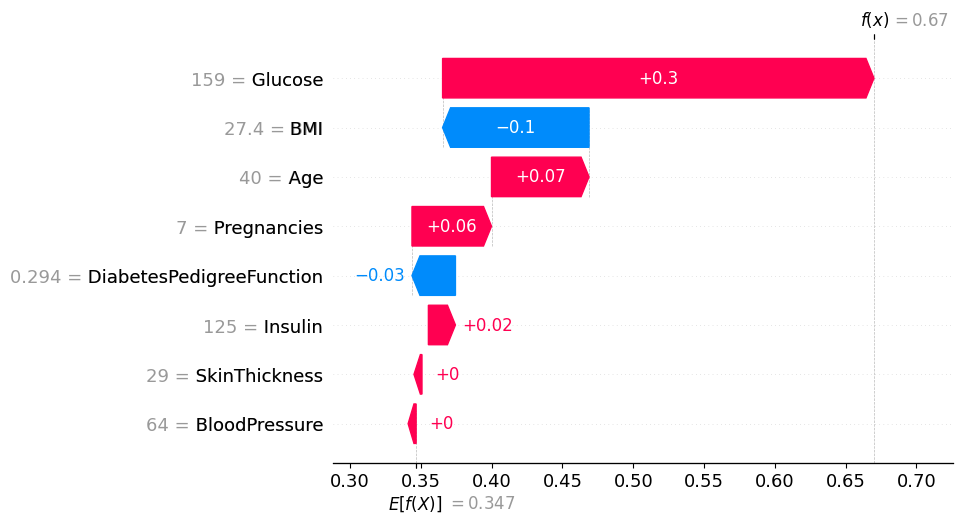


LIME EXPLANATION


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


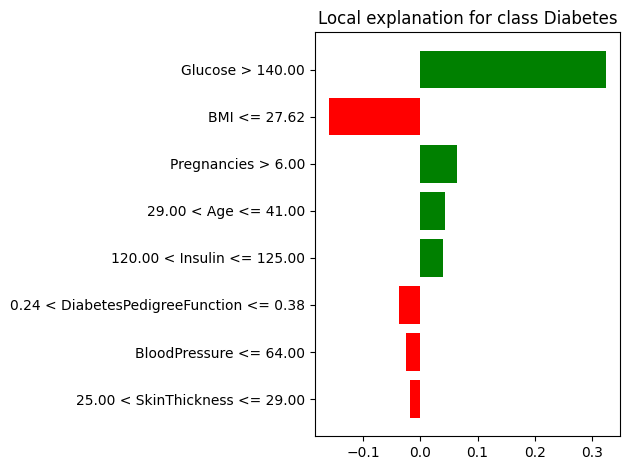


FINAL INTERPRETATION
The ML model predicts that this patient is likely to have diabetes.

SHAP explains how each feature contributed to this prediction.
LIME explains which features were important for this specific patient.

Note: This prediction is for academic demonstration only and is not a medical diagnosis.


In [30]:
explain_patient(0)

EXPLAINABLE AI - DIABETES PREDICTION

Patient Medical Information:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,29.0,125.0,27.4,0.294,40



Prediction: Diabetes
No Diabetes Probability: 33.0 %
Diabetes Probability: 67.0 %

SHAP EXPLANATION


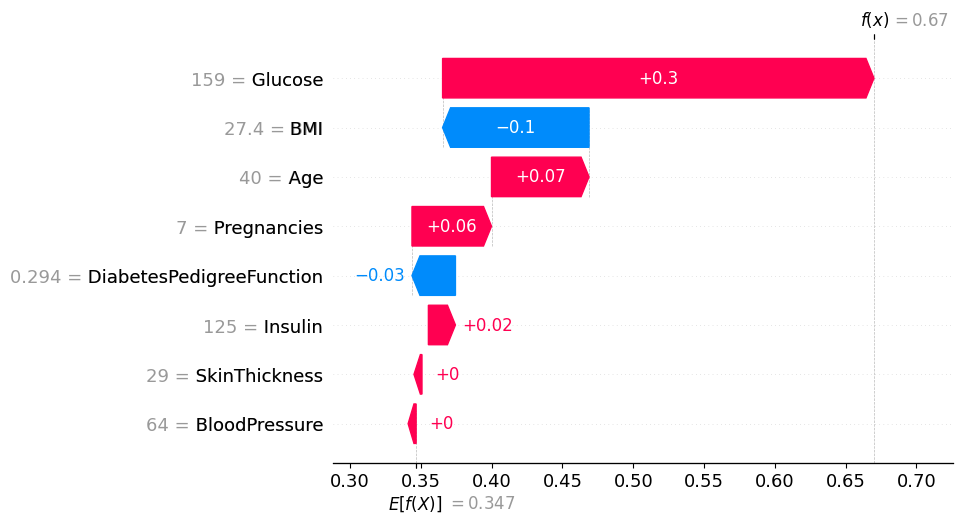


LIME EXPLANATION


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


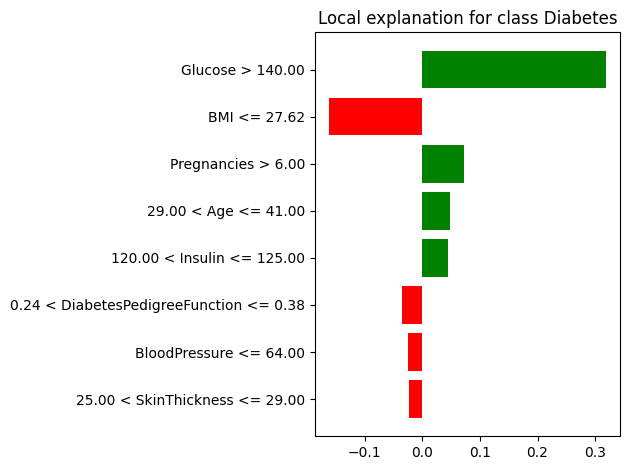


FINAL INTERPRETATION
The ML model predicts that this patient is likely to have diabetes.

SHAP explains how each feature contributed to this prediction.
LIME explains which features were important for this specific patient.

Note: This prediction is for academic demonstration only and is not a medical diagnosis.


In [31]:
explain_patient(0)

EXPLAINABLE AI - DIABETES PREDICTION

Patient Medical Information:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
389,3,100.0,68.0,23.0,81.0,31.6,0.949,28



Prediction: No Diabetes
No Diabetes Probability: 72.0 %
Diabetes Probability: 28.0 %

SHAP EXPLANATION


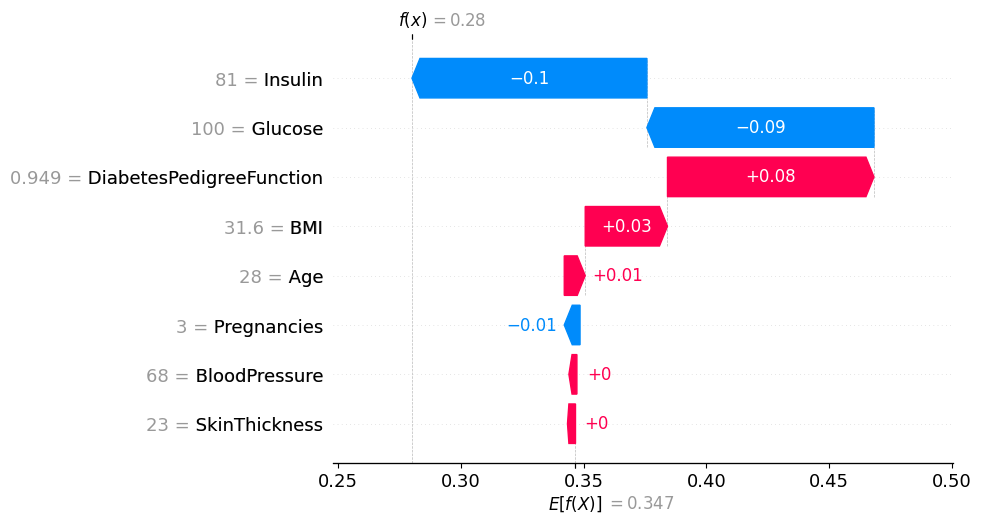


LIME EXPLANATION


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


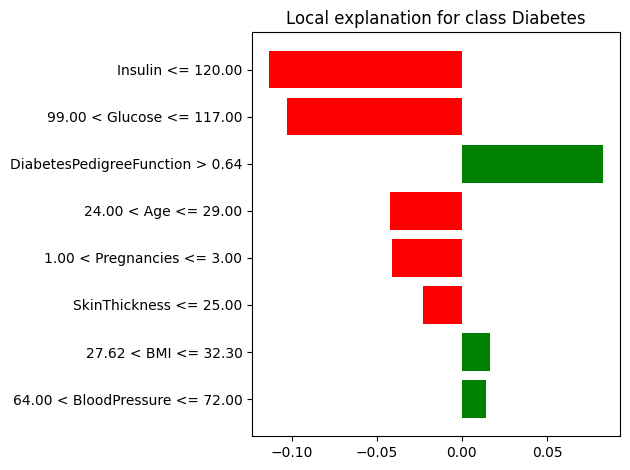


FINAL INTERPRETATION
The ML model predicts that this patient is likely not to have diabetes.

SHAP explains how each feature contributed to this prediction.
LIME explains which features were important for this specific patient.

Note: This prediction is for academic demonstration only and is not a medical diagnosis.


In [32]:
explain_patient(5)

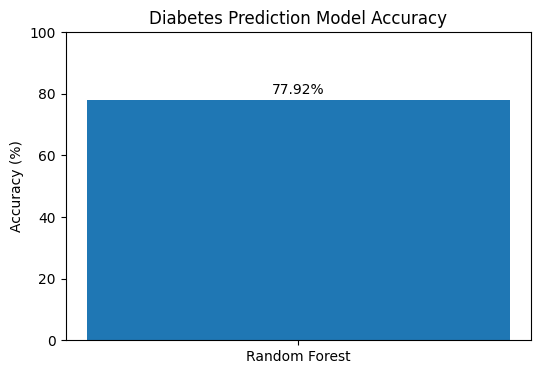

In [33]:
accuracy_percent = accuracy * 100

plt.figure(figsize=(6, 4))

plt.bar(
    ["Random Forest"],
    [accuracy_percent]
)

plt.ylabel("Accuracy (%)")
plt.title("Diabetes Prediction Model Accuracy")

plt.ylim(0, 100)

plt.text(
    0,
    accuracy_percent + 2,
    f"{accuracy_percent:.2f}%",
    ha="center"
)

plt.show()

In [34]:
print("=" * 70)
print("SHAP vs LIME - EXPLAINABLE AI COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    "Method": ["SHAP", "LIME"],
    "Purpose": [
        "Explains feature contribution to the prediction",
        "Explains important features for one specific prediction"
    ],
    "Explanation Type": [
        "Global + Local",
        "Local"
    ],
    "Used In This Project": [
        "Diabetes prediction",
        "Diabetes prediction"
    ]
})

display(comparison)

SHAP vs LIME - EXPLAINABLE AI COMPARISON


,Method,Purpose,Explanation Type,Used In This Project
0,SHAP,Explains feature contribution to the prediction,Global + Local,Diabetes prediction
1,LIME,Explains important features for one specific p...,Local,Diabetes prediction


In [35]:
# Calculate average absolute SHAP importance

mean_shap = np.abs(diabetes_shap).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": mean_shap
})

feature_importance = feature_importance.sort_values(
    "SHAP Importance",
    ascending=False
)

display(feature_importance)

,Feature,SHAP Importance
1,Glucose,0.134677
5,BMI,0.075481
7,Age,0.054773
6,DiabetesPedigreeFunction,0.041115
4,Insulin,0.034621
0,Pregnancies,0.027065
3,SkinThickness,0.020425
2,BloodPressure,0.014393


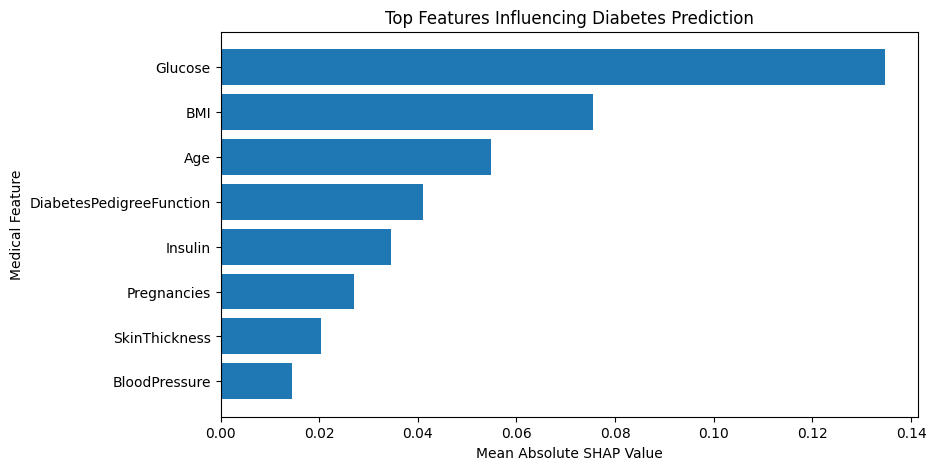

In [36]:
top_features = feature_importance.head(8)

plt.figure(figsize=(9, 5))

plt.barh(
    top_features["Feature"],
    top_features["SHAP Importance"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Medical Feature")
plt.title("Top Features Influencing Diabetes Prediction")

plt.gca().invert_yaxis()

plt.show()

In [37]:
print("=" * 70)
print("FINAL PROJECT RESULTS")
print("=" * 70)

print(f"\nModel Used: Random Forest")
print(f"Dataset Size: {len(df)} patients")
print(f"Number of Features: {X.shape[1]}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nExplainable AI Methods:")
print("1. SHAP - Feature contribution explanation")
print("2. LIME - Local patient-level explanation")

print("\nMedical Application:")
print("Diabetes Prediction")

print("\nProject Status:")
print("Completed Successfully")

FINAL PROJECT RESULTS

Model Used: Random Forest
Dataset Size: 768 patients
Number of Features: 8
Model Accuracy: 77.92%

Explainable AI Methods:
1. SHAP - Feature contribution explanation
2. LIME - Local patient-level explanation

Medical Application:
Diabetes Prediction

Project Status:
Completed Successfully
